<div style="text-align: center;">
    <hr style="border: 2px solid #FFB300; width: 90%; margin: 22px auto;">
    <h1 style="color: #1A237E; font-size: 2.5em; font-family: 'Arial Black', sans-serif;">
        DERMA SCAN IA DEMO 2: PREDIAGNÓSTICO DE ENFERMEDADES DE LA PIEL CON INTELIGENCIA ARTIFICIAL
    </h1>
    <hr style="border: 2px solid #FFB300; width: 90%; margin: 20px auto;">
    
    Realizado por: Samantha Suquilanda, Felipe Peralta, Andres Torres y Kevin Chipantiza
     
</div>

### INDICE
1. [  DESCRIPCIÓN](#introduccion-al-procesamiento-de-senales-biomedicas)  
2. [ANÁLISIS EXPLORATORIO](#adquisicion-y-digitalizacion-de-senales)  
2.1. [Descripción de la Problemática y Data set](#filtrado-y-eliminacion-de-ruido-en-senales-biomedicas)  
1.2.2. [Desafíos importantes](#gráfica-de-señales-principales)  
1.2.3. [Implicación en el desarrollo del modelo](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)  
2.4. [Visualización interactiva de imágenes por clase](#normalizar-una-senal)  
3. [ PROCESAMIENTO DE LA DATASET](#introduccion-al-procesamiento-de-senales-biomedicas)  
3.1 [Redimensión de imagenes a 224x224 píxeles](#adquisicion-y-digitalizacion-de-senales)  
3.2 [ División del Dataset en Conjuntos de Entrenamiento, Validación y Prueba](#filtrado-y-eliminacion-de-ruido-en-senales-biomedicas)  
4. [CONFIGURACIÓN BASE DEL ENTORNO](#gráfica-de-señales-principales)  
4.1. [Definición de Parámetros](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
4.2. [Carga de datos y transformaciones](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
4.3. [Creación de DataLoaders](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
4.4. [Definición y adaptación del modelo EfficientNet-B3](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
4.5. [Configuración de pérdida, Optimizador y Scheduler](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
4.6. [CEntrenamiento con validación y guardado del mejor modelo](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
4.7. [Visualización de curvas de pérdida y precisión](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
4.8. [Evaluación del modelo y análisis de rendimiento en el conjunto de prueba](#analisis-en-el-dominio-del-tiempo-y-la-frecuencia)
8. [Conclusiones](#normalizar-una-senal)  
<hr style="border: 1.5px solid #00008B;">


<span style="color:#800000; font-size:22px;">**1. DESCRIPCIÓN**</span>

En esta segunda versión del sistema DermaScan AI, se ha implementado una mejora significativa respecto al Demo 1. Mientras que la versión anterior utilizaba un conjunto reducido de datos con apenas 6 clases y alrededor de 38,000 imágenes, el nuevo sistema se entrena sobre el **Massive Skin Disease Balanced Dataset**, lo que representa un salto cualitativo y cuantitativo en el desarrollo del modelo.

Este nuevo dataset cuenta con:

- `262,874 imágenes` dermatológicas
- Clasificadas en `34 clases distintas` de enfermedades de la piel

Con un balance equitativo entre clases, lo que mejora notablemente la robustez y evita sesgos del modelo



<span style="color:#800000; font-size:22px;">**2. ANÁLISIS EXPLORATORIO**</span>

<span style="color:#00008B; font-size:18px;">**2.1 Descripción de la Problemática y Data set**:</span>


**Dataset utilizado:** `Massive Skin Disease Balanced Dataset`
Este dataset es una recopilación masiva y balanceada de imágenes dermatológicas utilizadas para tareas de clasificación de enfermedades cutáneas. Incluye imágenes en condiciones clínicas reales y ha sido diseñado para entrenamiento de modelos de deep learning.

**Fuentes de origen:**

- Dermnet Skin Diseases Database
- Dermatology Atlas
- Imágenes públicas de bases médicas
- Curación y etiquetado para fines de clasificación automática

**Las características del dataset son las siguientes:**

- Cantidad total de imágenes: Aproximadamente `262,874 imágenes`
- Número de clases o etiquetas: `34 categorías dermatológicas` balanceadas.

**Ejemplos de clases:**

  - Acne And Rosacea Photos
  - Atopic Dermatitis Photos
  - Cellulitis
  - Eczema Photos
  - Melanoma Skin Cancer Nevi And Moles
  - Psoriasis Pictures Lichen Planus And Related Diseases
  - Warts Molluscum And Other Viral Infections
  - Healthy, etc

<hr style="border: 1px solid #00008B;">

In [1]:
import os
from PIL import Image
from tqdm import tqdm
from collections import Counter
from PIL import Image
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd
import shutil
from sklearn.model_selection import train_test_split

In [2]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [3]:
# Extraer dentro de /content/
import zipfile
import os

zip_path = r'/content/drive/MyDrive//train_test_val.zip'             # Nombre del archivo subido
extract_to = "/content"            # Extraemos directamente en /content

with zipfile.ZipFile(zip_path, 'r') as zip_ref:
    zip_ref.extractall(extract_to)  # Esto dejará /content/ si tu .zip contiene la carpeta

# Verifica si existe la carpeta y muestra algunos archivos
train_path = "/content/train_test_val"
if os.path.exists(train_path):
    print("Archivos en content/:", os.listdir(train_path)[:5])
else:
    print("No se encontró la carpeta 'train' después de descomprimir.")

Archivos en content/: ['val', '.DS_Store', 'train', 'test']


In [ ]:
dataset_path = './archive/balanced_dataset/balanced_dataset'

class_dirs = [d for d in os.listdir(dataset_path) if os.path.isdir(os.path.join(dataset_path, d))]

image_counts = {}
image_sizes = []

for class_name in class_dirs:
    class_path = os.path.join(dataset_path, class_name)
    image_files = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    image_counts[class_name] = len(image_files)

    for image_name in image_files:
        image_path = os.path.join(class_path, image_name)
        try:
            with Image.open(image_path) as img:
                width, height = img.size
                image_sizes.append((width, height))
        except Exception as e:
            print(f"Error al leer la imagen {image_path}: {e}")

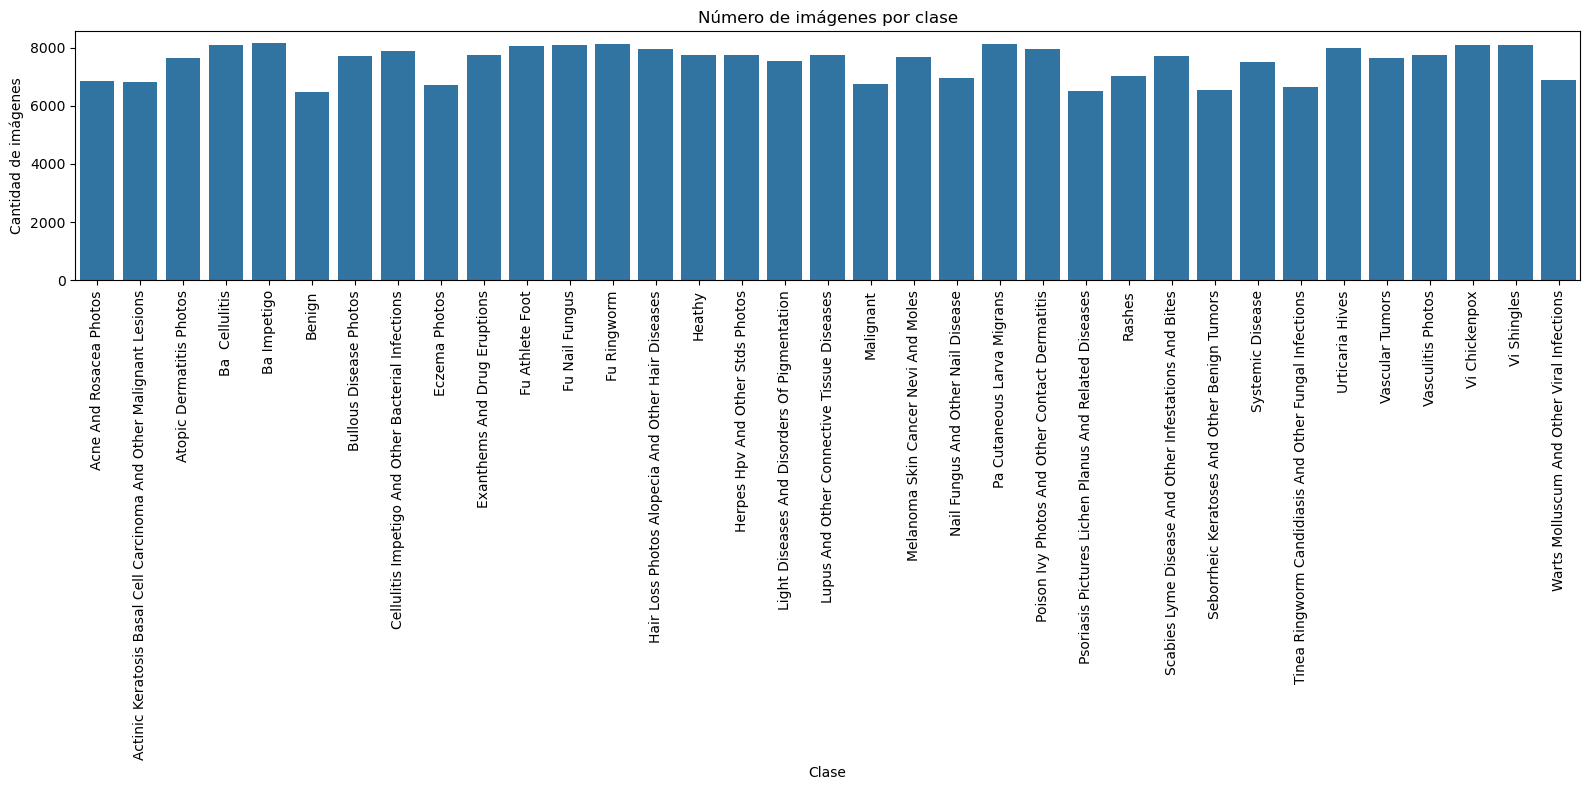

,"Resolution (W, H)",Count
0,"(224, 224)",45425
1,"(720, 472)",40629
2,"(720, 480)",20338
3,"(480, 720)",10024
4,"(128, 128)",8083
5,"(720, 464)",5583
6,"(720, 474)",4960
7,"(720, 477)",4696
8,"(472, 720)",3678
9,"(477, 720)",2841


In [ ]:
plt.figure(figsize=(16, 8))
sns.barplot(x=list(image_counts.keys()), y=list(image_counts.values()))
plt.xticks(rotation=90)
plt.title("Número de imágenes por clase")
plt.ylabel("Cantidad de imágenes")
plt.xlabel("Clase")
plt.tight_layout()
plt.show()

size_counter = Counter(image_sizes)
df_sizes = pd.DataFrame(size_counter.items(), columns=['Resolution (W, H)', 'Count']).sort_values(by='Count', ascending=False)
df_sizes.reset_index(drop=True, inplace=True)

df_sizes.head(10)


- **Distribución de imágenes:** Balanceada por clase (entre `6,000 y 8,200` imágenes por categoría), como se observa en el histograma generado. La clase `“Healthy”` también está presente y puede ser usada como piel sana.
- **Estructura de carpetas:** Organizado por subcarpetas con nombre de la clase, ideal para cargas con ImageDataGenerator o torchvision.datasets.ImageFolder.
- **Dimensiones de entrada:** Las imágenes presentan tamaños variables. Se recomienda redimensionarlas a `224 × 224 píxeles`, en formato RGB (3 canales), para estandarizar su entrada a la red neuronal.
- **Formato de etiquetas:** Las carpetas están nombradas por clase, no hay codificación numérica directa (esto debe hacerse al cargar).

<span style="color:#00008B; font-size:18px;">**2.2 Desafíos importantes**:</span>
Este dataset incluye imágenes capturadas en condiciones reales, por lo que el entrenamiento de modelos debe considerar lo siguiente:

* Variabilidad en la calidad de imagen y resolución.
* Cambios en el tono de piel y condiciones de iluminación.
* Posiciones y encuadres no estandarizados.
* Algunas imágenes pueden incluir fondos complejos.

<span style="color:#00008B; font-size:18px;">**2.3 Implicación en el desarrollo del modelo**:</span>
Gracias a su tamaño y balance, este dataset es ideal para entrenar modelos robustos de clasificación multicategoría. Además, al incluir la clase *"Healthy"*, se puede aplicar directamente para:

* Clasificación binaria: Sano vs Enfermo
* Clasificación multicategoría: Healthy + 34 enfermedades



<span style="color:#00008B; font-size:18px;">**2.4 Visualización interactiva de imágenes por clase**:</span>

- Permite seleccionar una clase desde un menú desplegable.
- Muestra 5 imágenes aleatorias de esa clase usando matplotlib.
- Útil para explorar visualmente el dataset y validar su estructura.

Facilita la inspección rápida de los datos antes del entrenamiento.

In [ ]:
import os
import random
import matplotlib.pyplot as plt
from PIL import Image
from ipywidgets import interact, fixed

# Ruta a tu dataset
data_dir = r"D:\ALEXANDER\kevin\Documents\GitHub\Proyecto-Final-Inteligencia-Artificial\modelo-final\train_test_val\train"

# Configuración
num_images_per_class = 5

# Obtener clases (subcarpetas)
classes = sorted([d for d in os.listdir(data_dir) if os.path.isdir(os.path.join(data_dir, d))])

def mostrar_clase(Clase, data_dir):
    class_path = os.path.join(data_dir, Clase)
    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    # Selección aleatoria de imágenes
    selected_images = random.sample(images, min(num_images_per_class, len(images)))

    # Crear figura
    fig, axes = plt.subplots(1, num_images_per_class, figsize=(num_images_per_class * 3, 3))

    for idx, image_name in enumerate(selected_images):
        img_path = os.path.join(class_path, image_name)
        image = Image.open(img_path).convert("RGB")

        axes[idx].imshow(image)
        axes[idx].axis("off")
        axes[idx].set_title(f"{Clase}", fontsize=10)

    plt.suptitle(f"Clase: {Clase} ", fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

# Crear widget interactivo
interact(mostrar_clase, Clase=classes, data_dir=fixed(data_dir));


interactive(children=(Dropdown(description='Clase', options=('Acne And Rosacea Photos', 'Actinic Keratosis Bas…

<span style="color:#800000; font-size:22px;">**3. PROCESAMIENTO DE LA DATASET**</span>

<span style="color:#00008B; font-size:18px;">**3.1 Redimensión de imagenes a 224x224 píxeles**:</span>

Este script recorre todas las imágenes del dataset original `"balanced_dataset"`, que contiene subcarpetas por clase, y realiza los siguientes pasos:

- Crea una nueva carpeta de salida `(./redimension) para almacenar` las imágenes procesadas.
- Lee cada imagen del conjunto original, clase por clase.
- Convierte la imagen a `formato RGB` para estandarizar canales de color.
- Redimensiona cada imagen a `224×224 píxeles`, tamaño ideal para modelos de deep learning como `EfficientNet o ResNet`.
- Guarda la imagen redimensionada en la carpeta correspondiente a su clase, manteniendo la estructura original del dataset.

Esto asegura que todo el conjunto de datos esté normalizado en tamaño y formato, facilitando su uso en el entrenamiento de modelos de clasificación de imágenes.

<hr style="border: 1.5px solid #00008B;">

In [ ]:
# Rutas
original_path = './archive/balanced_dataset/balanced_dataset'
resized_path = './redimension'
target_size = (224, 224)

os.makedirs(resized_path, exist_ok=True)

for class_name in os.listdir(original_path):
    class_dir = os.path.join(original_path, class_name)
    if not os.path.isdir(class_dir):
        continue

    target_class_dir = os.path.join(resized_path, class_name)
    os.makedirs(target_class_dir, exist_ok=True)

    for image_name in tqdm(os.listdir(class_dir), desc=f"Procesando {class_name}"):
        if not image_name.lower().endswith(('.jpg', '.jpeg', '.png')):
            continue

        src_path = os.path.join(class_dir, image_name)
        dst_path = os.path.join(target_class_dir, image_name)

        try:
            with Image.open(src_path) as img:
                img = img.convert("RGB")
                img_resized = img.resize(target_size)
                img_resized.save(dst_path)
        except Exception as e:
            print(f"Error con la imagen {src_path}: {e}")


Procesando Acne And Rosacea Photos: 100%|██████████| 6837/6837 [00:26<00:00, 260.42it/s]
Procesando Actinic Keratosis Basal Cell Carcinoma And Other Malignant Lesions: 100%|██████████| 6821/6821 [00:26<00:00, 261.91it/s]
Procesando Bullous Disease Photos: 100%|██████████| 7695/7695 [00:27<00:00, 275.36it/s]
Procesando Cellulitis Impetigo And Other Bacterial Infections: 100%|██████████| 7894/7894 [00:28<00:00, 276.53it/s]
Procesando Fu Ringworm: 100%|██████████| 8129/8129 [00:07<00:00, 1058.27it/s]
Procesando Hair Loss Photos Alopecia And Other Hair Diseases: 100%|██████████| 7955/7955 [00:29<00:00, 266.45it/s]
Procesando Herpes Hpv And Other Stds Photos: 100%|██████████| 7744/7744 [00:27<00:00, 277.85it/s]
Procesando Light Diseases And Disorders Of Pigmentation: 100%|██████████| 7546/7546 [00:26<00:00, 284.73it/s]
Procesando Lupus And Other Connective Tissue Diseases: 100%|██████████| 7734/7734 [00:27<00:00, 278.56it/s]
Procesando Pa Cutaneous Larva Migrans: 100%|██████████| 8123/8123 

<span style="color:#00008B; font-size:18px;">**3.2 División del Dataset en Conjuntos de Entrenamiento, Validación y Prueba**:</span>
Este script organiza automáticamente las imágenes del dataset redimensionado (./redimension) en tres subconjuntos: entrenamiento (70%), validación (15%) y prueba (15%). Para cada clase:

- Lee todas las imágenes correspondientes a esa clase.
- Divide aleatoriamente las imágenes en proporciones definidas usando train_test_split.
- Copia las imágenes a sus respectivas carpetas (./train_test/train, ./train_test/val, ./train_test/test) manteniendo la estructura por clase.
- Crea carpetas si no existen, asegurando una estructura compatible con ImageFolder de PyTorch o Keras.
  
<hr style="border: 1.5px solid #00008B;">

In [ ]:
source_dir = './redimension'
target_dir = './train_test'
os.makedirs(target_dir, exist_ok=True)

train_pct = 0.7
val_pct = 0.15
test_pct = 0.15

splits = ['train', 'val', 'test']
for split in splits:
    os.makedirs(os.path.join(target_dir, split), exist_ok=True)

for class_name in tqdm(os.listdir(source_dir), desc="Dividiendo dataset por clase"):
    class_path = os.path.join(source_dir, class_name)
    if not os.path.isdir(class_path):
        continue

    images = [f for f in os.listdir(class_path) if f.lower().endswith(('.jpg', '.jpeg', '.png'))]

    train_imgs, temp_imgs = train_test_split(images, test_size=(1 - train_pct), random_state=42)
    val_imgs, test_imgs = train_test_split(temp_imgs, test_size=(test_pct / (val_pct + test_pct)), random_state=42)

    def copy_images(img_list, split):
        split_class_dir = os.path.join(target_dir, split, class_name)
        os.makedirs(split_class_dir, exist_ok=True)
        for img in img_list:
            src = os.path.join(class_path, img)
            dst = os.path.join(split_class_dir, img)
            shutil.copy2(src, dst)

    copy_images(train_imgs, 'train')
    copy_images(val_imgs, 'val')
    copy_images(test_imgs, 'test')


Dividiendo dataset por clase: 100%|██████████| 35/35 [00:29<00:00,  1.20it/s]


In [4]:
!pip install efficientnet_pytorch

  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 2.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 121.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 102.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 62.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 1.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 11.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 41.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 19.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 4.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 108.7 MB/s eta 0:00:00
  Created wheel for efficientnet_pytorch: filename=efficientnet_pytorch-0.7.1-py3-none-any.whl size=16426 sha256=3c5f1b6b57630652afd04894a50818338996db18ae39

<span style="color:#800000; font-size:22px;">**4. CONFIGURACIÓN BASE DEL ENTORNO**</span>

In [5]:
# Exportar Librerías
import os
import torch
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from torchvision import datasets, transforms
from torch.utils.data import DataLoader, WeightedRandomSampler
from sklearn.metrics import classification_report, confusion_matrix

from efficientnet_pytorch import EfficientNet
import torch.nn as nn
import torch.optim as optim

print(" Celda completada: Librerías importadas")

 Celda completada: Librerías importadas


<span style="color:#00008B; font-size:18px;">**4.1 Definición de Parámetros**:</span>
En esta celda se definen los parámetros fundamentales para el entrenamiento del modelo:

- `SEED = 42`: Se fija una semilla para asegurar reproducibilidad en los experimentos, es decir, que los resultados sean consistentes entre ejecuciones.
- `BATCH_SIZE = 32`: Tamaño del lote o cantidad de imágenes que se procesan simultáneamente durante cada paso de entrenamiento.
- `IMG_SIZE = 224`: Tamaño al que se redimensionan todas las imágenes, compatible con modelos como EfficientNet o ResNet.

In [6]:
#  Configuraciones base
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Usando:", device)

SEED = 42
torch.manual_seed(SEED)

BATCH_SIZE = 32
IMG_SIZE = 224

print("Configuración general completada")


Usando: cuda
Configuración general completada


<span style="color:#00008B; font-size:18px;">**4.2 Carga de datos y transformaciones**:</span>

- Se define la ruta al dataset ya dividido en carpetas (train, val, test).
- Se aplican transformaciones de aumento de datos para train y normalización para val y test.
- Se cargan los datos con ImageFolder y se detecta automáticamente el número de clases (NUM_CLASSES).

Permite preparar los datos de forma eficiente para el entrenamiento del modelo.

In [7]:

# Ruta local a tu dataset separado
data_dir = r"/content/train_test_val"

# Transformaciones
train_transforms = transforms.Compose([
    transforms.RandomResizedCrop(IMG_SIZE),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

val_test_transforms = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize([0.5]*3, [0.5]*3)
])

# Carga directa desde carpetas ya divididas
train_dataset = datasets.ImageFolder(os.path.join(data_dir, "train"), transform=train_transforms)
val_dataset   = datasets.ImageFolder(os.path.join(data_dir, "val"),   transform=val_test_transforms)
test_dataset  = datasets.ImageFolder(os.path.join(data_dir, "test"),  transform=val_test_transforms)

NUM_CLASSES = len(train_dataset.classes)
print("Clases detectadas:", train_dataset.classes)
print(" Celda completada: Datos cargados directamente desde las carpetas predivididas.")


Clases detectadas: ['Acne And Rosacea Photos', 'Actinic Keratosis Basal Cell Carcinoma And Other Malignant Lesions', 'Atopic Dermatitis Photos', 'Ba  Cellulitis', 'Ba Impetigo', 'Benign', 'Bullous Disease Photos', 'Cellulitis Impetigo And Other Bacterial Infections', 'Eczema Photos', 'Exanthems And Drug Eruptions', 'Fu Athlete Foot', 'Fu Nail Fungus', 'Fu Ringworm', 'Hair Loss Photos Alopecia And Other Hair Diseases', 'Heathy', 'Herpes Hpv And Other Stds Photos', 'Light Diseases And Disorders Of Pigmentation', 'Lupus And Other Connective Tissue Diseases', 'Malignant', 'Melanoma Skin Cancer Nevi And Moles', 'Nail Fungus And Other Nail Disease', 'Pa Cutaneous Larva Migrans', 'Poison Ivy Photos And Other Contact Dermatitis', 'Psoriasis Pictures Lichen Planus And Related Diseases', 'Rashes', 'Scabies Lyme Disease And Other Infestations And Bites', 'Seborrheic Keratoses And Other Benign Tumors', 'Systemic Disease', 'Tatoo', 'Tinea Ringworm Candidiasis And Other Fungal Infections', 'Urticari

<span style="color:#00008B; font-size:18px;">**4.3  Creación de DataLoaders**:</span>

- Se crean DataLoaders para entrenamiento, validación y prueba.
- El conjunto de entrenamiento usa shuffle=True para aleatorizar los datos.
- Validación y prueba se cargan en orden fijo (shuffle=False).

Facilita el manejo eficiente y estructurado de los datos durante el entrenamiento y evaluación.

In [8]:
# Creación de DataLoaders
from torch.utils.data import DataLoader

# Crear los DataLoaders con barajado en entrenamiento y orden fijo en validación/prueba
train_loader = DataLoader(train_dataset, batch_size=BATCH_SIZE, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=BATCH_SIZE, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=BATCH_SIZE, shuffle=False)

print(" Celda completada: DataLoaders creados.")


 Celda completada: DataLoaders creados.


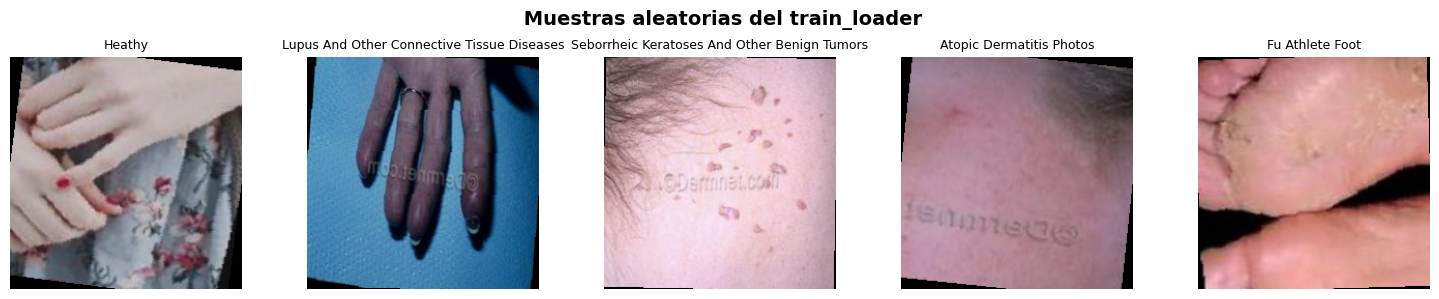

In [9]:
# Visualización de un batch del train_loader
import matplotlib.pyplot as plt
import torchvision

# Obtener un batch aleatorio del train_loader
images, labels = next(iter(train_loader))

# Número de imágenes a mostrar (ajusta si deseas)
num_images = min(5, len(images))

# Desnormalizar imágenes para visualización
def denormalize(tensor):
    tensor = tensor * 0.5 + 0.5  # Inverso de Normalize([0.5]*3, [0.5]*3)
    return tensor.clamp(0, 1)

# Crear una figura
fig, axes = plt.subplots(1, num_images, figsize=(num_images * 3, 3))

# Mostrar imágenes con sus etiquetas
for i in range(num_images):
    img = denormalize(images[i])  # Desnormalizar para mostrar
    img = img.permute(1, 2, 0).numpy()  # Convertir de [C,H,W] a [H,W,C]

    axes[i].imshow(img)
    axes[i].axis('off')
    class_idx = labels[i].item()
    axes[i].set_title(train_dataset.classes[class_idx], fontsize=9)

plt.suptitle(" Muestras aleatorias del train_loader", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()



<span style="color:#00008B; font-size:18px;">**4.4 Definición y adaptación del modelo EfficientNet-B3**:</span>

Esta celda carga un modelo EfficientNet-B3 preentrenado y lo ajusta para una tarea de clasificación personalizada. Las modificaciones incluyen:

- Importación del modelo preentrenado desde efficientnet_pytorch.
- Reemplazo de la capa final (fully connected) por una nueva secuencia con:
- Dropout de 0.4 para prevenir sobreajuste.
- Capa lineal con salida igual a NUM_CLASSES, adaptada al número de clases del dataset.

Este paso configura el modelo para que pueda aprender a clasificar las clases específicas de tu conjunto de datos.

In [10]:
from efficientnet_pytorch import EfficientNet
import torch.nn as nn
import torch

# Cargar modelo preentrenado EfficientNet-B3
model = EfficientNet.from_pretrained('efficientnet-b3')

# Reemplazar la capa final por una nueva con Dropout y salida ajustada al número de clases
in_features = model._fc.in_features
model._fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

# Enviar el modelo al dispositivo seleccionado
model = model.to(device)

print(" Modelo EfficientNet-B3 cargado con Dropout(0.4) y listo para entrenamiento.")


Downloading: "https://github.com/lukemelas/EfficientNet-PyTorch/releases/download/1.0/efficientnet-b3-5fb5a3c3.pth" to /root/.cache/torch/hub/checkpoints/efficientnet-b3-5fb5a3c3.pth
100%|██████████| 47.1M/47.1M [00:01<00:00, 48.3MB/s]


Loaded pretrained weights for efficientnet-b3
 Modelo EfficientNet-B3 cargado con Dropout(0.4) y listo para entrenamiento.


<span style="color:#00008B; font-size:18px;">**4.5 Configuración de pérdida, Optimizador y Scheduler**:</span>


- Se usa `CrossEntropyLoss` para clasificación multiclase.
- Se aplica el optimizador `Adam` con `lr = 1e-4`.
- Se incluye un scheduler `ReduceLROnPlateau` que reduce el learning rate si la pérdida de validación no mejora tras 3 épocas.

Permite un entrenamiento estable y adaptativo del modelo.

In [11]:
# Definición de la Función de Pérdida, Optimizador y Scheduler de Aprendizaje
import torch.nn as nn
import torch.optim as optim

# Función de pérdida para clasificación multiclase
criterion = nn.CrossEntropyLoss()

# Optimizador Adam con tasa de aprendizaje inicial
learning_rate = 1e-4
optimizer = optim.Adam(model.parameters(), lr=learning_rate)

# Scheduler que reduce el LR si la pérdida de validación no mejora
scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=3 # Espera 3 epochs sin mejora
)

print(" Celda completada: Función de pérdida, optimizador Adam y scheduler definidos.")


 Celda completada: Función de pérdida, optimizador Adam y scheduler definidos.


<span style="color:#00008B; font-size:18px;">**4.6 Entrenamiento con validación y guardado del mejor modelo**:</span>


- Se entrena el modelo por 20 épocas usando los train_loader y val_loader.
- Se calculan y registran precisión y pérdida para entrenamiento y validación.
- El scheduler ajusta el learning rate si la validación no mejora.
- Se guarda automáticamente el mejor checkpoint (Mejor_Modelo.pth) cuando la pérdida de validación es la más baja.

Ideal para monitorear el desempeño del modelo y conservar su mejor versión.

In [12]:
import time
import torch
from tqdm import tqdm  # Barra de progreso

EPOCHS = 10
best_val_loss = float('inf')
SAVE_INTERVAL = 1  # Cada cuántos epochs guardar el progreso en archivo

train_losses, val_losses = [], []
train_accuracies, val_accuracies = [], []

model.to(device)

for epoch in range(EPOCHS):
    start_time = time.time()

    # Entrenamiento
    model.train()
    running_loss = 0.0
    correct, total = 0, 0

    print(f"\n🔁 Epoch {epoch+1}/{EPOCHS}")
    for inputs, labels in tqdm(train_loader, desc="Entrenando"):
        inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, preds = torch.max(outputs, 1)
        correct += (preds == labels).sum().item()
        total += labels.size(0)

    avg_train_loss = running_loss / len(train_loader)
    train_accuracy = correct / total
    train_losses.append(avg_train_loss)
    train_accuracies.append(train_accuracy)

    # Validación
    model.eval()
    val_loss = 0.0
    val_correct, val_total = 0, 0

    with torch.no_grad():
        for inputs, labels in tqdm(val_loader, desc="Validando"):
            inputs, labels = inputs.to(device, non_blocking=True), labels.to(device, non_blocking=True)
            outputs = model(inputs)
            loss = criterion(outputs, labels)

            val_loss += loss.item()
            _, preds = torch.max(outputs, 1)
            val_correct += (preds == labels).sum().item()
            val_total += labels.size(0)

    avg_val_loss = val_loss / len(val_loader)
    val_accuracy = val_correct / val_total
    val_losses.append(avg_val_loss)
    val_accuracies.append(val_accuracy)

    scheduler.step(avg_val_loss)

    end_time = time.time()
    epoch_time = end_time - start_time

    print(f"\n📊 Epoch {epoch+1}/{EPOCHS} "
          f"| Train Loss: {avg_train_loss:.4f} | Train Acc: {train_accuracy:.4f} "
          f"| Val Loss: {avg_val_loss:.4f} | Val Acc: {val_accuracy:.4f} "
          f"| ⏱ Tiempo: {epoch_time:.2f} s")

    # Guardar el mejor modelo
    if avg_val_loss < best_val_loss:
        best_val_loss = avg_val_loss
        torch.save({
            'model_state_dict': model.state_dict(),
            'optimizer_state_dict': optimizer.state_dict(),
            'scheduler_state_dict': scheduler.state_dict(),
            'val_loss': avg_val_loss,
            'epoch': epoch,
            'num_classes': NUM_CLASSES
        }, "Mejor_Modelo.pth")
        print("✅ Modelo guardado (nuevo mejor)")

    # Guardar progreso en archivo de texto
    if (epoch + 1) % SAVE_INTERVAL == 0:
        with open("entrenamiento_log.txt", "a") as f:
            f.write(f"Epoch {epoch+1}/{EPOCHS}, "
                    f"Train Loss: {avg_train_loss:.4f}, Train Acc: {train_accuracy:.4f}, "
                    f"Val Loss: {avg_val_loss:.4f}, Val Acc: {val_accuracy:.4f}, "
                    f"Time: {epoch_time:.2f} s\n")

print("\n🏁 Entrenamiento finalizado")



🔁 Epoch 1/10


Validando: 100%|██████████| 1265/1265 [01:20<00:00, 15.69it/s]



📊 Epoch 1/10 | Train Loss: 1.4640 | Train Acc: 0.5824 | Val Loss: 0.6017 | Val Acc: 0.8190 | ⏱ Tiempo: 1124.97 s
✅ Modelo guardado (nuevo mejor)

🔁 Epoch 2/10


Validando: 100%|██████████| 1265/1265 [01:20<00:00, 15.68it/s]



📊 Epoch 2/10 | Train Loss: 0.7873 | Train Acc: 0.7666 | Val Loss: 0.3222 | Val Acc: 0.9016 | ⏱ Tiempo: 1127.46 s
✅ Modelo guardado (nuevo mejor)

🔁 Epoch 3/10


...


📊 Epoch 8/10 | Train Loss: 0.2995 | Train Acc: 0.9078 | Val Loss: 0.0782 | Val Acc: 0.9748 | ⏱ Tiempo: 1116.80 s
✅ Modelo guardado (nuevo mejor)

🔁 Epoch 9/10


Validando: 100%|██████████| 1265/1265 [01:20<00:00, 15.80it/s]



📊 Epoch 9/10 | Train Loss: 0.2773 | Train Acc: 0.9145 | Val Loss: 0.0773 | Val Acc: 0.9751 | ⏱ Tiempo: 1117.22 s
✅ Modelo guardado (nuevo mejor)

🔁 Epoch 10/10


Validando: 100%|██████████| 1265/1265 [01:20<00:00, 15.74it/s]



📊 Epoch 10/10 | Train Loss: 0.2614 | Train Acc: 0.9195 | Val Loss: 0.0743 | Val Acc: 0.9764 | ⏱ Tiempo: 1119.99 s
✅ Modelo guardado (nuevo mejor)

🏁 Entrenamiento finalizado


<span style="color:#00008B; font-size:18px;">**4.7 Visualización de curvas de pérdida y precisión**:</span>

**Visualización de curvas de pérdida y precisión:**
Se grafican las curvas de pérdida y exactitud (accuracy) durante las épocas, tanto para entrenamiento como validación. Estas gráficas permiten identificar si hay sobreajuste o subajuste en el modelo.

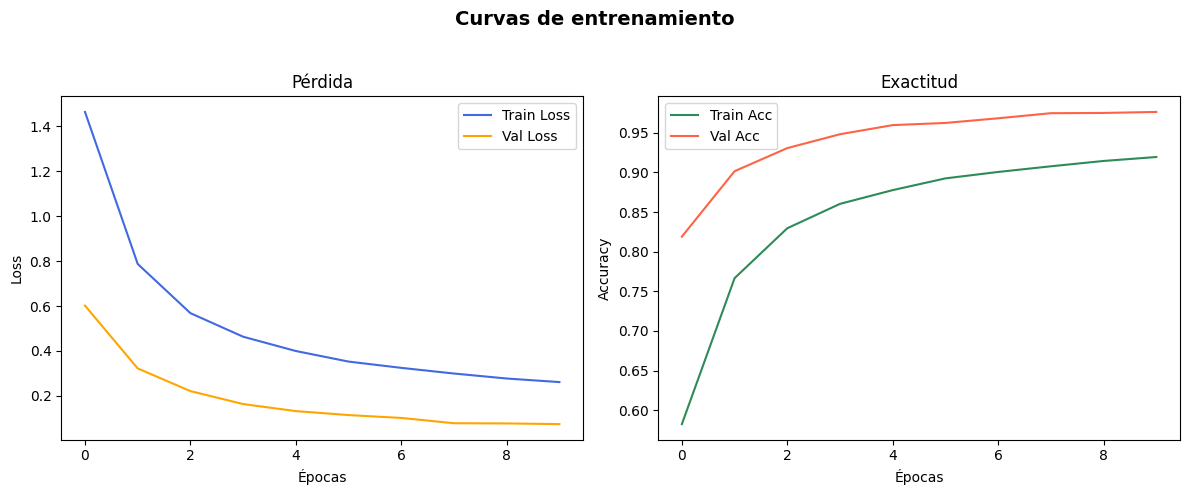

 Celda completada: Gráficas mostradas y guardadas como 'curvas_entrenamiento.png'


In [13]:
# Curvas de pérdida y precisión
import matplotlib.pyplot as plt

# Crear figura
plt.figure(figsize=(12, 5))

# Subplot de pérdida
plt.subplot(1, 2, 1)
plt.plot(train_losses, label="Train Loss", color='royalblue')
plt.plot(val_losses, label="Val Loss", color='orange')
plt.title("Pérdida")
plt.xlabel("Épocas")
plt.ylabel("Loss")
plt.legend()

# Subplot de precisión
plt.subplot(1, 2, 2)
plt.plot(train_accuracies, label="Train Acc", color='seagreen')
plt.plot(val_accuracies, label="Val Acc", color='tomato')
plt.title("Exactitud")
plt.xlabel("Épocas")
plt.ylabel("Accuracy")
plt.legend()

# Título general y ajustes
plt.suptitle("Curvas de entrenamiento", fontsize=14, fontweight='bold')
plt.tight_layout(rect=[0, 0, 1, 0.95])

#  Guardar como imagen
plt.savefig("curvas_entrenamiento.png", dpi=300, bbox_inches='tight')

# Mostrar
plt.show()

print(" Celda completada: Gráficas mostradas y guardadas como 'curvas_entrenamiento.png'")


<span style="color:#00008B; font-size:18px;">**4.8 Evaluación del modelo y análisis de rendimiento en el conjunto de prueba**:</span>

✅ Modelo EfficientNet-B3 cargado correctamente.

📋 Clasificación por clase:
                                                                    precision    recall  f1-score   support

                                           Acne And Rosacea Photos       0.96      0.97      0.96      1026
Actinic Keratosis Basal Cell Carcinoma And Other Malignant Lesions       0.96      0.96      0.96      1024
                                          Atopic Dermatitis Photos       0.98      0.98      0.98      1147
                                                    Ba  Cellulitis       1.00      1.00      1.00      1212
                                                       Ba Impetigo       1.00      1.00      1.00      1223
                                                            Benign       0.96      0.98      0.97       969
                                            Bullous Disease Photos       0.99      1.00      1.00      1155
                Cellulitis Impetigo And Other Bacterial Inf

/usr/local/lib/python3.11/dist-packages/IPython/core/pylabtools.py:151: UserWarning: Glyph 128269 (\N{LEFT-POINTING MAGNIFYING GLASS}) missing from font(s) DejaVu Sans.
  fig.canvas.print_figure(bytes_io, **kw)


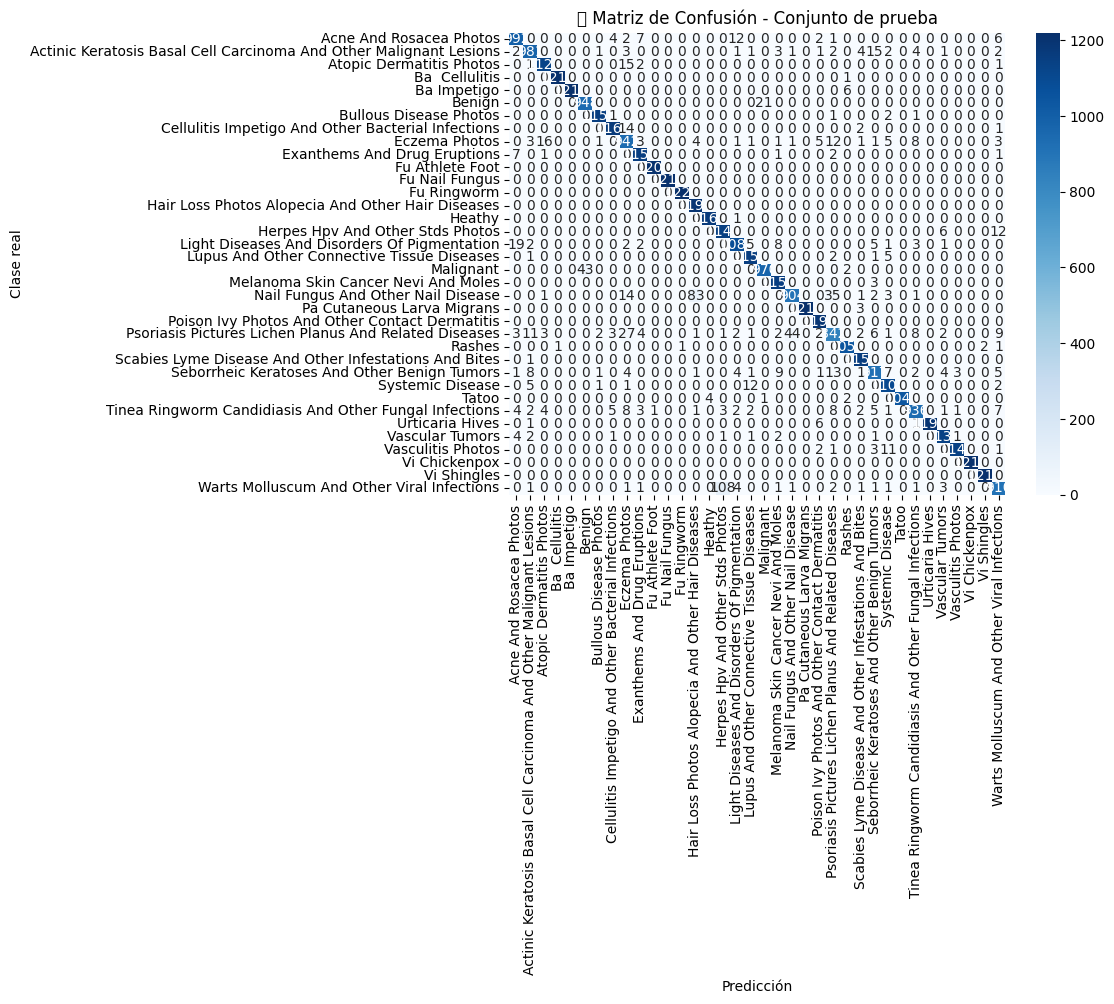

Evaluación finalizada.


In [20]:
# Evaluación del modelo EfficientNet-B3 previamente entrenado
import torch
import torch.nn as nn
from efficientnet_pytorch import EfficientNet
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# Dispositivo
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

# Cargar checkpoint
checkpoint = torch.load("Mejor_Modelo.pth", map_location=device)
NUM_CLASSES = checkpoint['num_classes']  # Recuperar número de clases desde el checkpoint

# Reconstruir modelo EfficientNet-B3 con capa final personalizada
model = EfficientNet.from_name('efficientnet-b3')  # No usamos from_pretrained
in_features = model._fc.in_features
model._fc = nn.Sequential(
    nn.Dropout(0.4),
    nn.Linear(in_features, NUM_CLASSES)
)

# Cargar pesos
model.load_state_dict(checkpoint['model_state_dict'])
model.to(device)
model.eval()
print("✅ Modelo EfficientNet-B3 cargado correctamente.")

# Evaluación
all_preds = []
all_labels = []

with torch.no_grad():
    for inputs, labels in test_loader:
        inputs = inputs.to(device)
        labels = labels.to(device)
        outputs = model(inputs)
        _, preds = torch.max(outputs, 1)
        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

# Reporte de clasificación
class_names = train_dataset.classes
print("\n📋 Clasificación por clase:")
print(classification_report(all_labels, all_preds, target_names=class_names))

# Matriz de confusión
cm = confusion_matrix(all_labels, all_preds)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues",
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicción")
plt.ylabel("Clase real")
plt.title("🔍 Matriz de Confusión - Conjunto de prueba")
plt.show()

print("Evaluación finalizada.")


<span style="color:#800000; font-size:22px;">**5. CONCLUSIONES**</span>